In [1]:
import matplotlib.pyplot as plt
import pickle
import numpy as np
from pathlib import Path

legend_properties = {'weight': 'bold'}

In [2]:
# Data folder
# Mac path for the Hybrid turbulence experiment on re-centralization degree.
data_folder = Path(r"/Volumes/T7/data/dao-0310-23/V4_4/Hybrid_turbulence")

prefix = "hybrid_turbulence"

recentralization_list_file = data_folder / f"{prefix}_recentralization_list"
performance_file = data_folder / f"{prefix}_performance"
diversity_file = data_folder / f"{prefix}_diversity"
variance_file = data_folder / f"{prefix}_variance"
cv_file = data_folder / f"{prefix}_cv"
consensus_performance_file = data_folder / f"{prefix}_consensus_performance"
entropy_file = data_folder / f"{prefix}_entropy"
antagonism_file = data_folder / f"{prefix}_antagonism"
mode_file = data_folder / f"{prefix}_mode"

with open(recentralization_list_file, 'rb') as infile:
    recentralization_list = pickle.load(infile)
with open(performance_file, 'rb') as infile:
    hybrid_performance = pickle.load(infile)
with open(diversity_file, 'rb') as infile:
    hybrid_diversity = pickle.load(infile)
with open(variance_file, 'rb') as infile:
    hybrid_variance = pickle.load(infile)
with open(cv_file, 'rb') as infile:
    hybrid_cv = pickle.load(infile)
with open(consensus_performance_file, 'rb') as infile:
    hybrid_consensus_performance = pickle.load(infile)
with open(entropy_file, 'rb') as infile:
    hybrid_entropy = pickle.load(infile)
with open(antagonism_file, 'rb') as infile:
    hybrid_antagonism = pickle.load(infile)

# mode is diagnostic; it is large and not necessary for core plots.
# Load it only when needed.
try:
    with open(mode_file, 'rb') as infile:
        hybrid_mode = pickle.load(infile)
except FileNotFoundError:
    hybrid_mode = None

# Convert to arrays: shape = [len(recentralization_list), search_loop]
hybrid_performance = np.array(hybrid_performance)
hybrid_diversity = np.array(hybrid_diversity)
hybrid_variance = np.array(hybrid_variance)
hybrid_cv = np.array(hybrid_cv)
hybrid_consensus_performance = np.array(hybrid_consensus_performance)
hybrid_entropy = np.array(hybrid_entropy)
hybrid_antagonism = np.array(hybrid_antagonism)
recentralization_array = np.array(recentralization_list)

print("Performance shape:", hybrid_performance.shape)
print("Consensus shape:", hybrid_consensus_performance.shape)


Performance shape: (21, 1000)
Consensus shape: (21, 1000)


In [3]:
# Define more colors
# NUS two colors
nus_blue = "#003D7C"
nus_orange = "#EF7C00"
# Nature three colors
nature_orange = "#F16C23"
nature_blue = "#2B6A99"
nature_green = "#1B7C3D"
# Morandi six colors
morandi_blue = "#046586"
morandi_green =  "#28A9A1"
morandi_yellow = "#C9A77C"
morandi_orange = "#F4A016"
morandi_pink = "#F6BBC6"
morandi_red = "#E71F19"
morandi_purple = "#B08BEB"
# Others
shallow_grey = "#D3D4D3"
deep_grey = "#A6ABB6"

In [4]:
# Helper functions

def set_axis_style(ax):
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["right"].set_linewidth(1.5)
    ax.spines["top"].set_linewidth(1.5)
    ax.spines["bottom"].set_linewidth(1.5)


def final_value(matrix):
    """Return final-period value for each re-centralization level."""
    return np.array(matrix)[:, -1]


def window_average(matrix, window=100):
    """Return average over the last `window` periods for each re-centralization level.

    For the turbulence experiment, window=100 matches one full turbulence cycle
    when turbulence_freq=100.
    """
    matrix = np.array(matrix)
    return np.mean(matrix[:, -window:], axis=1)


def post_burn_in_average(matrix, burn_in=500):
    """Return average after burn-in for each re-centralization level.

    This is useful as a robustness check because turbulent performance may
    fluctuate across cycles rather than converge to one final value.
    """
    matrix = np.array(matrix)
    return np.mean(matrix[:, burn_in:], axis=1)


def savefig(name):
    plt.savefig(data_folder / name, transparent=True, dpi=300, bbox_inches='tight')


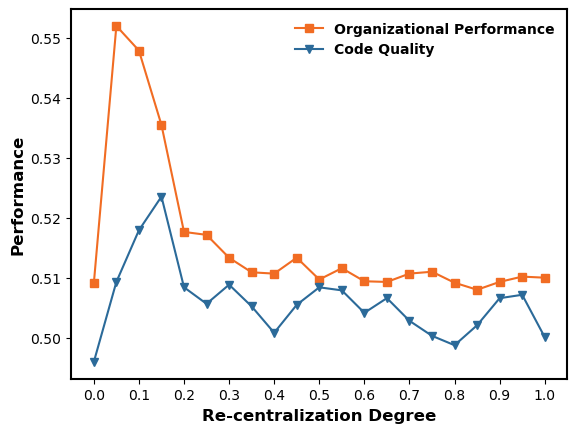

<Figure size 640x480 with 0 Axes>

In [5]:
# Primary turbulent figure:
# Impact of re-centralization on performance using the last-cycle average.
#
# Why not only the final point?
# Under turbulence, performance may fluctuate after each environmental change.
# The last-cycle average preserves the same figure logic as the static evaluator
# while avoiding dependence on one arbitrary terminal period.

order = np.argsort(recentralization_array)

x = recentralization_array[order]
individual_eval = np.array(window_average(hybrid_performance, window=100))[order]
consensus_eval = np.array(window_average(hybrid_consensus_performance, window=100))[order]

fig, ax = plt.subplots()
set_axis_style(ax)

ax.plot(x, individual_eval, "-s", color=nature_orange,
        label="Organizational Performance")
ax.plot(x, consensus_eval, "-v", color=nature_blue,
        label="Code Quality")

plt.xlabel(r'Re-centralization Degree', fontweight='bold', fontsize=12)
plt.ylabel('Performance', fontweight='bold', fontsize=12)
plt.xticks(np.arange(0, 1.01, 0.1))
ax.legend(frameon=False, ncol=1, fontsize=12, prop=legend_properties)

savefig("Turbulence_Performance_across_hybrid_degree_last_cycle.png")
plt.show()
plt.clf()


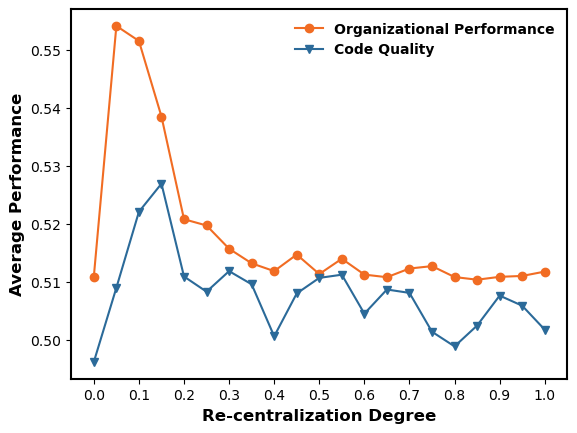

<Figure size 640x480 with 0 Axes>

In [16]:
# Primary turbulent figure:
# Impact of re-centralization on performance using the average performance
# across the last 20% of the search period.
#
# Why not only the final point?
# Under turbulence, performance may fluctuate after each environmental change.
# The last-20% average preserves the same figure logic as the static evaluator
# while avoiding dependence on one arbitrary terminal period.

def last_percent_average(matrix, percent=0.20):
    matrix = np.array(matrix)
    window = int(matrix.shape[1] * percent)
    return np.mean(matrix[:, -window:], axis=1)

order = np.argsort(recentralization_array)

x = recentralization_array[order]
individual_eval = np.array(last_percent_average(hybrid_performance, percent=0.20))[order]
consensus_eval = np.array(last_percent_average(hybrid_consensus_performance, percent=0.20))[order]

fig, ax = plt.subplots()
set_axis_style(ax)

ax.plot(x, individual_eval, "-o", color=nature_orange,
        label="Organizational Performance")
ax.plot(x, consensus_eval, "-v", color=nature_blue,
        label="Code Quality")

plt.xlabel(r"Re-centralization Degree", fontweight="bold", fontsize=12)
plt.ylabel("Average Performance", fontweight="bold", fontsize=12)
plt.xticks(np.arange(0, 1.01, 0.1))
ax.legend(frameon=False, ncol=1, fontsize=12, prop=legend_properties)

savefig("Turbulence_Performance_across_hybrid_degree_last_20_percent.png")
plt.show()
plt.clf()

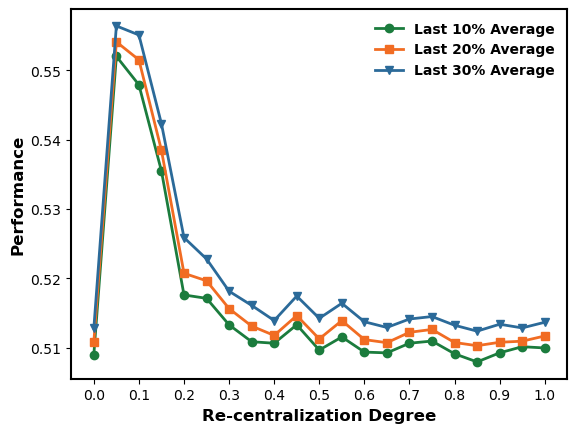

<Figure size 640x480 with 0 Axes>

In [20]:
# Robustness figure:
# Compare alternative long-run averaging windows.
# 1. Last 10% of periods
# 2. Last 20% of periods
# 3. Last 30% of periods

def last_percent_average(matrix, percent=0.20):
    matrix = np.array(matrix)
    window = int(matrix.shape[1] * percent)
    return np.mean(matrix[:, -window:], axis=1)

order = np.argsort(recentralization_array)
x = recentralization_array[order]

fig, ax = plt.subplots()
set_axis_style(ax)

ax.plot(
    x,
    last_percent_average(hybrid_performance, percent=0.10)[order],
    "-o",
    color=nature_green,
    linewidth=2,
    label="Last 10% Average"
)

ax.plot(
    x,
    last_percent_average(hybrid_performance, percent=0.20)[order],
    "-s",
    color=nature_orange,
    linewidth=2,
    label="Last 20% Average"
)

ax.plot(
    x,
    last_percent_average(hybrid_performance, percent=0.30)[order],
    "-v",
    color=nature_blue,
    linewidth=2,
    label="Last 30% Average"
)

plt.xlabel(
    r"Re-centralization Degree",
    fontweight="bold",
    fontsize=12
)
plt.ylabel(
    "Performance",
    fontweight="bold",
    fontsize=12
)

plt.xticks(np.arange(0, 1.01, 0.1))

ax.legend(
    frameon=False,
    ncol=1,
    fontsize=12,
    prop=legend_properties
)

savefig("hybrid_turbulence_performance_window_robustness.png")
plt.show()
plt.clf()

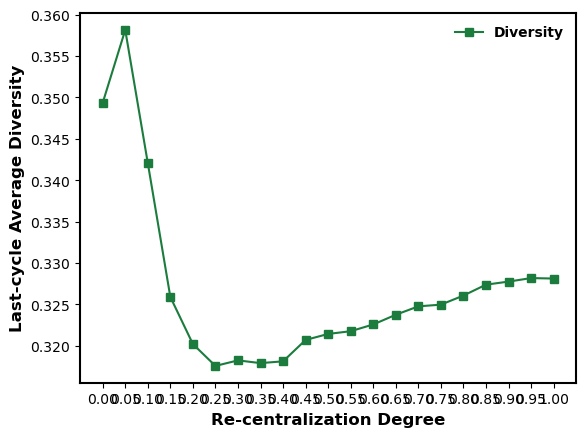

<Figure size 640x480 with 0 Axes>

In [7]:
# Impact of re-centralization on diversity
fig, ax = plt.subplots()
set_axis_style(ax)

ax.plot(recentralization_array, window_average(hybrid_diversity, window=100), "-s", color=nature_green,
        label="Diversity")

plt.xlabel(r'Re-centralization Degree', fontweight='bold', fontsize=12)
plt.ylabel('Last-cycle Average Diversity', fontweight='bold', fontsize=12)
plt.xticks(recentralization_array)
ax.legend(frameon=False, ncol=1, fontsize=12, prop=legend_properties)
savefig("hybrid_turbulence_recentralization_last_cycle_diversity.png")
plt.show()
plt.clf()


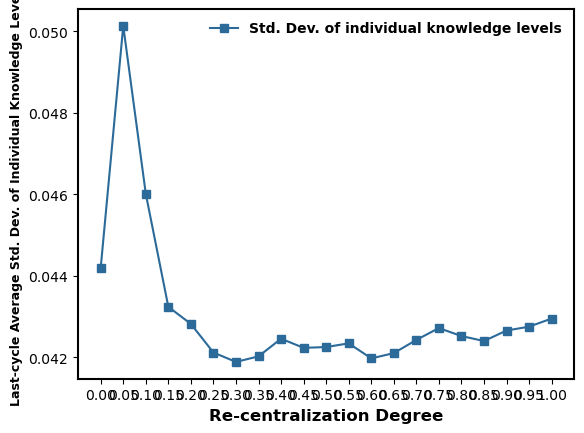

<Figure size 640x480 with 0 Axes>

In [8]:
# Impact of re-centralization on variance
fig, ax = plt.subplots()
set_axis_style(ax)

ax.plot(recentralization_array, window_average(hybrid_variance, window=100), "-s", color=nature_blue,
        label="Std. Dev. of individual knowledge levels")

plt.xlabel(r'Re-centralization Degree', fontweight='bold', fontsize=12)
plt.ylabel('Last-cycle Average Std. Dev. of Individual Knowledge Levels', fontweight='bold', fontsize=9)
plt.xticks(recentralization_array)
ax.legend(frameon=False, ncol=1, fontsize=12, prop=legend_properties)
savefig("hybrid_turbulence_recentralization_last_cycle_sd.png")
plt.show()
plt.clf()


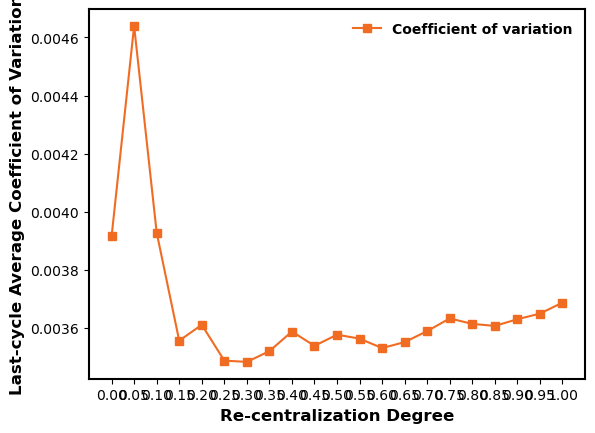

<Figure size 640x480 with 0 Axes>

In [9]:
# Impact of re-centralization on coefficient of variation
fig, ax = plt.subplots()
set_axis_style(ax)

ax.plot(recentralization_array, window_average(hybrid_cv, window=100), "-s", color=nature_orange,
        label="Coefficient of variation")

plt.xlabel(r'Re-centralization Degree', fontweight='bold', fontsize=12)
plt.ylabel('Last-cycle Average Coefficient of Variation', fontweight='bold', fontsize=12)
plt.xticks(recentralization_array)
ax.legend(frameon=False, ncol=1, fontsize=12, prop=legend_properties)
savefig("hybrid_turbulence_recentralization_last_cycle_cv.png")
plt.show()
plt.clf()


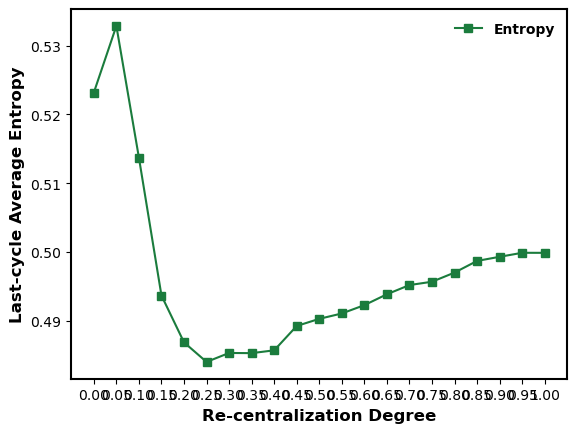

<Figure size 640x480 with 0 Axes>

In [10]:
# Impact of re-centralization on entropy
fig, ax = plt.subplots()
set_axis_style(ax)

ax.plot(recentralization_array, window_average(hybrid_entropy, window=100), "-s", color=nature_green,
        label="Entropy")

plt.xlabel(r'Re-centralization Degree', fontweight='bold', fontsize=12)
plt.ylabel('Last-cycle Average Entropy', fontweight='bold', fontsize=12)
plt.xticks(recentralization_array)
ax.legend(frameon=False, ncol=1, fontsize=12, prop=legend_properties)
savefig("hybrid_turbulence_recentralization_last_cycle_entropy.png")
plt.show()
plt.clf()


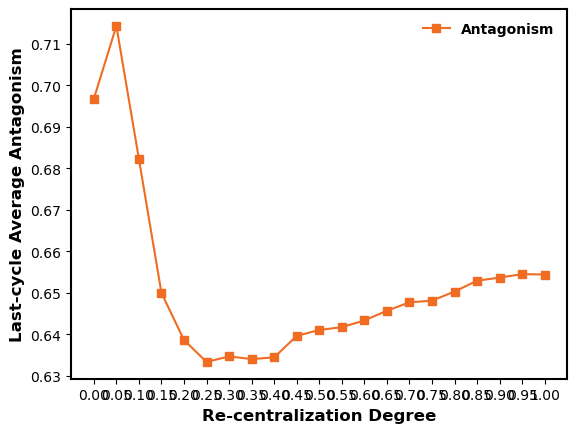

<Figure size 640x480 with 0 Axes>

In [11]:
# Impact of re-centralization on antagonism
fig, ax = plt.subplots()
set_axis_style(ax)

ax.plot(recentralization_array, window_average(hybrid_antagonism, window=100), "-s", color=nature_orange,
        label="Antagonism")

plt.xlabel(r'Re-centralization Degree', fontweight='bold', fontsize=12)
plt.ylabel('Last-cycle Average Antagonism', fontweight='bold', fontsize=12)
plt.xticks(recentralization_array)
ax.legend(frameon=False, ncol=1, fontsize=12, prop=legend_properties)
savefig("hybrid_turbulence_recentralization_last_cycle_antagonism.png")
plt.show()
plt.clf()


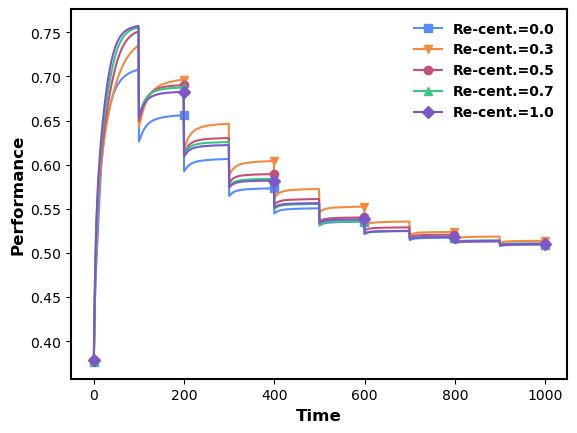

<Figure size 640x480 with 0 Axes>

In [12]:
# Time trajectories by selected re-centralization values
selected_recentralization_values = [0.0, 0.3, 0.5, 0.7, 1.0]
selected_indices = [int(np.argmin(np.abs(recentralization_array - recentralization))) for recentralization in selected_recentralization_values]
x = range(hybrid_performance.shape[1])
marker_positions = np.linspace(0, len(x) - 1, num=6, dtype=int)

fig, ax = plt.subplots()
set_axis_style(ax)

markers = ["s", "v", "o", "^", "D"]
for idx, marker in zip(selected_indices, markers):
    ax.plot(x, hybrid_performance[idx], "-" + marker,
            label=rf"Re-cent.={recentralization_array[idx]:.1f}",
            markevery=marker_positions)

plt.xlabel('Time', fontweight='bold', fontsize=12)
plt.ylabel('Performance', fontweight='bold', fontsize=12)
ax.legend(frameon=False, ncol=1, fontsize=12, prop=legend_properties)
# savefig("hybrid_recentralization_performance_trajectories.png")
plt.show()
plt.clf()

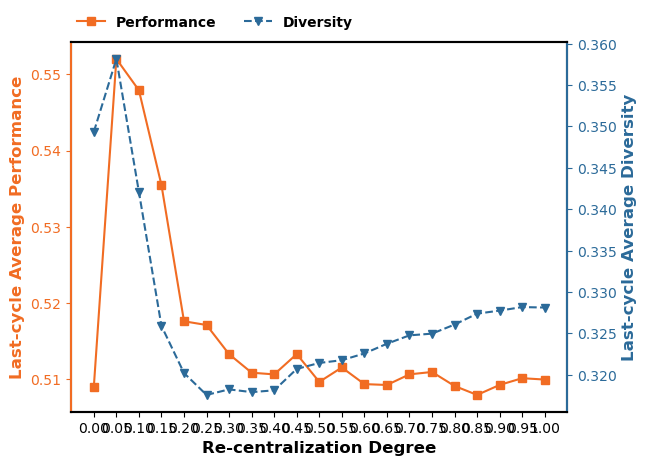

<Figure size 640x480 with 0 Axes>

In [13]:
# Twin plot: turbulent performance and diversity across re-centralization
# Both outcomes use the last-cycle average.

fig, ax1 = plt.subplots()
ax1.set_xlabel(r'Re-centralization Degree', fontweight='bold', fontsize=12)
ax1.set_ylabel('Last-cycle Average Performance', fontweight='bold', color="black", fontsize=12)

ax2 = ax1.twinx()
ax2.set_ylabel('Last-cycle Average Diversity', fontweight='bold', color="black", fontsize=12)

ax2.spines['left'].set_color(nature_orange)
ax1.yaxis.label.set_color(nature_orange)
ax1.tick_params(axis='y', colors=nature_orange)
ax2.spines['right'].set_color(nature_blue)
ax2.yaxis.label.set_color(nature_blue)
ax2.tick_params(axis='y', colors=nature_blue)

set_axis_style(ax1)
set_axis_style(ax2)

line_1 = ax1.plot(recentralization_array, window_average(hybrid_performance, window=100), "-s",
                  label="Performance", color=nature_orange)
line_2 = ax2.plot(recentralization_array, window_average(hybrid_diversity, window=100), "--v",
                  label="Diversity", color=nature_blue)

plt.xticks(recentralization_array)
lines = line_1 + line_2
labs = [line.get_label() for line in lines]
ax1.legend(lines, labs, frameon=False, fontsize=12, loc=(0, 1.02),
           ncol=2, prop=legend_properties)

savefig("hybrid_turbulence_recentralization_performance_diversity_last_cycle.png")
plt.show()
plt.clf()
